<a href="https://colab.research.google.com/github/HazemHassan2009/Breast-cancer-predictions/blob/main/Breast_cancer_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Breast cancer prediction
* Task 1: Data Loading & Initial Overview
* Task 2: Data Cleaning and Preprocessing
* Task 3: Feature Selection
* Task 4: PCA and K-Means Clustering
* Task 5: DBSCAN Clustering for Outlier Detection
* Task 6: Find the Most Similar Patients
* Task 7: Neural Network Model Training
* Task 8: Model Evaluation, Bias Check, and Ethics
* Summary

### Task 1: Data Loading & Initial Overview

In [ ]:
#import all necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest , f_classif
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading the dataset
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BreastCancer.csv')
df.sample(10)

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
694,776715,3,1,1,1,3,2.0,1,1,1,0
107,1170420,1,6,8,10,8,10.0,5,7,1,1
367,160296,5,8,8,10,5,10.0,8,10,3,1
60,1115282,5,3,5,5,3,3.0,4,10,1,1
351,837082,2,1,1,1,2,1.0,3,1,1,0
289,555977,5,6,6,8,6,10.0,4,10,4,1
524,749653,3,1,1,1,2,1.0,2,1,1,0
680,1369821,10,10,10,10,5,10.0,10,10,7,1
598,1333495,3,1,1,1,2,1.0,2,1,1,0
139,1183246,1,1,1,1,1,NaN,2,1,1,0


In [ ]:
#checking the dimensions of the dataset
print(df.shape)

(699, 11)


In [ ]:
#statical summary of the dataset
df.describe()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413,0.344778
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078,0.475636
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,0.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,1.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


### Task 2: Data Cleaning and Preprocessing

In [ ]:
# checking data types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               699 non-null    int64  
 1   Cl.thickness     699 non-null    int64  
 2   Cell.size        699 non-null    int64  
 3   Cell.shape       699 non-null    int64  
 4   Marg.adhesion    699 non-null    int64  
 5   Epith.c.size     699 non-null    int64  
 6   Bare.nuclei      683 non-null    float64
 7   Bl.cromatin      699 non-null    int64  
 8   Normal.nucleoli  699 non-null    int64  
 9   Mitoses          699 non-null    int64  
 10  Class            699 non-null    int64  
dtypes: float64(1), int64(10)
memory usage: 60.2 KB
None


In [ ]:
#checking for missing values
print(df.isnull().sum())

Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               0
dtype: int64


In [ ]:
#finding duplicate rows
print(df.duplicated().sum())

8


the column 'Bare.nuclei' has missing values and it's type is gloat although it doesn't have decimel values and is numbered from 1 to 10. also there's 8 duplicated values,lastly the id column has no correltion with breast cancer

In [ ]:
# Fill missing values and changing to integer
df['Bare.nuclei'] = df['Bare.nuclei'].fillna(df['Bare.nuclei'].median()).astype(int)

In [ ]:
#droping duplicate rows
df = df.drop_duplicates()

In [ ]:
#dropping the 'Id' column as it is not useful for prediction
df = df.drop(['Id'], axis=1)

In [ ]:
#separating features and target variable
x = df.drop(['Class'], axis=1)
y = df['Class']

now the our data is clean and ready

### Task 3: Feature Selection

In [ ]:
#scalling the data
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

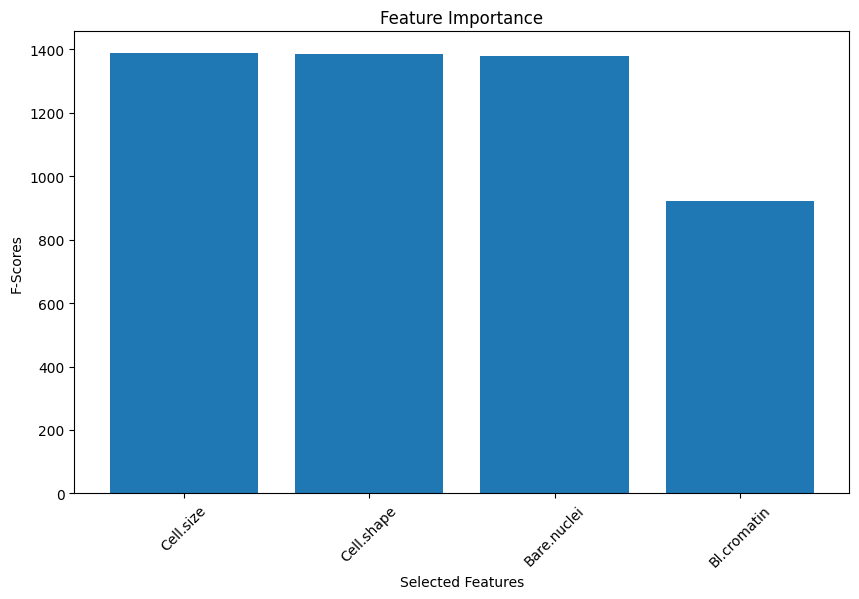

In [ ]:
#selecting the best 5 features
feature_selector = SelectKBest(score_func=f_classif, k=4)
x_selected = feature_selector.fit_transform(x_scaled, y)

#plotting the selected features
selected_features_indices = feature_selector.get_support(indices=True)
output_selected_features = x.columns[selected_features_indices]
plt.figure(figsize=(10, 6))
plt.bar(range(len(output_selected_features)), feature_selector.scores_[selected_features_indices])
plt.xlabel('Selected Features')
plt.ylabel('F-Scores')
plt.title('Feature Importance')
plt.xticks(range(len(output_selected_features)), output_selected_features, rotation=45)
plt.show()

we notice that 'cell.size', 'cell.shape' and 'bare.nuclei' are the most important and significant after them comes 'BI.cromatin' the other features are less in score

### Task 4: PCA & K-Means Clustering

In [ ]:
#performing PCA for dimensionality reduction
pca = PCA(n_components=2)
x_pca=pca.fit_transform(x_selected)

the dimensionality reduction is used to save time and computing power while still getting accurate predictions

In [ ]:
#k-means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(x_pca)

Text(0.5, 1.0, 'K-Means Clustering Results')

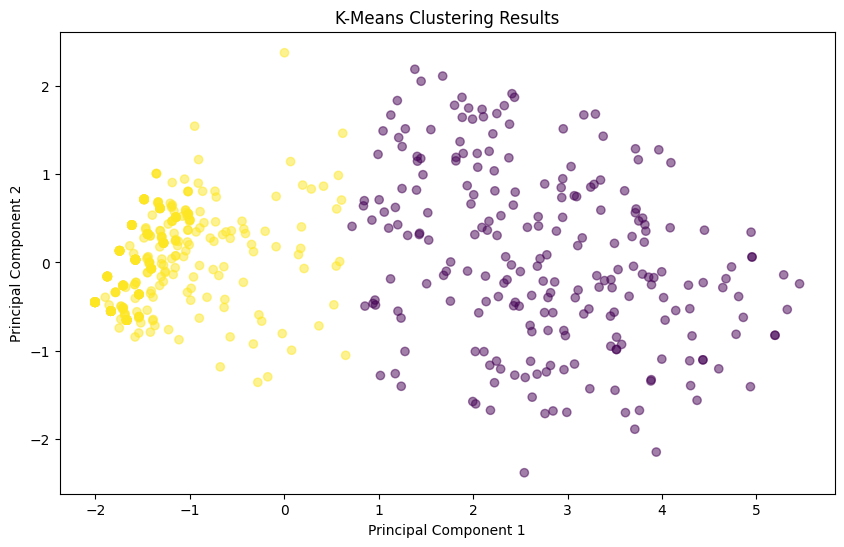

In [ ]:
#plotting the clusters
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering Results')

we see that kmeans made two groups one smaller and one bigger. the smaller resembles higher-risk malignant traits and the bigger resembles lower-risk benign characteristics

### Task 5: DBSCAN Outlier Detection

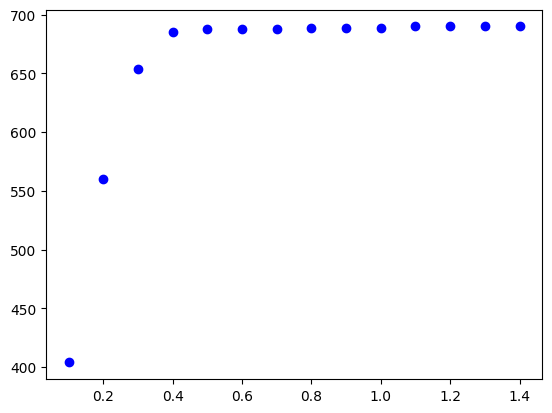

In [ ]:
#makine elbow plot to find the optimal eps value for DBSCAN
eps_values = np.arange(0.1, 1.5, 0.1)
inertia_values = []
for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=4)
    dbscan_labels = dbscan.fit_predict(x_pca)
    inertia_values.append(np.sum(dbscan_labels != -1))  # Count of non-noise points
    plt.plot(eps, inertia_values[-1], 'o', color='blue')

we notice the elbow at 0.4

In [ ]:
# DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=4)
dbscan_labels = dbscan.fit_predict(x_pca)

In [ ]:
# Count how many outliers (-1) were detected
num_outliers = list(dbscan_labels).count(-1)
print(f"Number of outliers detected: {num_outliers}")

Number of outliers detected: 5


Text(0.5, 1.0, 'DBSCAN Clustering')

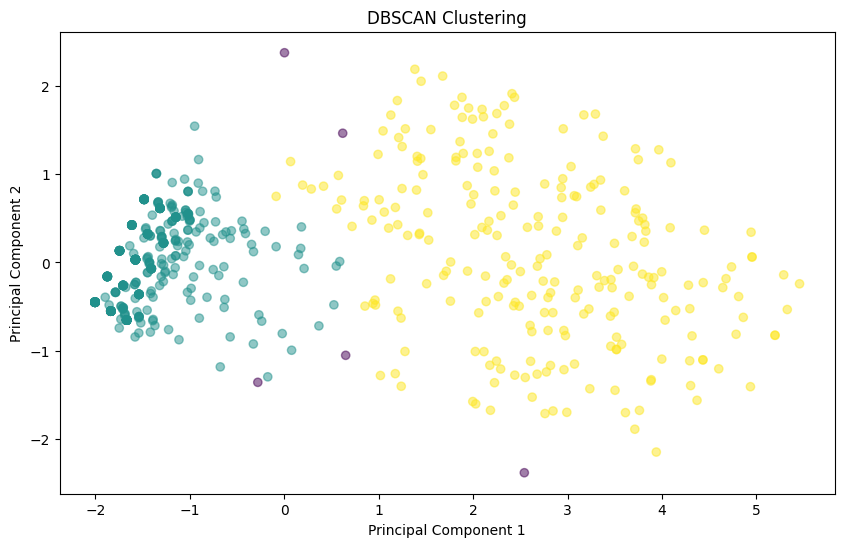

In [ ]:
# plotting the DBSCAN clusters
plt.figure(figsize=(10, 6))
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clustering')

We DBSCAN notices 5 outleirs

### Task 6: Patient Similarity Recommendation

Content-based similarity: items (here patient records) are compared by their feature vectors. High similarity means patients share similar cytological measurements.

In [ ]:
# Compute cosine similarity on the selected, scaled features and provide helpers to inspect results.
cosine_sim = cosine_similarity(x_selected)
similarity_df = pd.DataFrame(cosine_sim, index=df.index, columns=df.index)

def top_similar(patient_idx, n=3):
          scores = cosine_sim[patient_idx].copy()
          scores[patient_idx] = -1.0  # exclude self
          top_idx = np.argsort(scores)[-n:][::-1]
          return pd.Series(scores[top_idx], index=df.index[top_idx])

def interpret_score(score):
          if score >= 0.9:
                    return "very high similarity (nearly identical cytology)"
          if score >= 0.7:
                    return "high similarity"
          if score >= 0.4:
                    return "moderate similarity"
          if score >= 0.0:
                    return "low similarity"
          return "dissimilar / opposite patterns"

# Examples: top 3 similar patients for patient 0 and for patient 696 (a malignant example)
top3_for_0 = top_similar(0, 3)
def top_similar(patient_idx, n=3):
          if patient_idx in df.index:
                    patient_idx = df.index.get_loc(patient_idx)
          elif not (0 <= patient_idx < len(df)):
                    raise IndexError(f"patient_idx {patient_idx} is out of bounds for {len(df)} rows")
          scores = cosine_sim[patient_idx].copy()
          scores[patient_idx] = -1.0
          top_idx = np.argsort(scores)[-n:][::-1]
          return pd.Series(scores[top_idx], index=df.index[top_idx])

print("Top 3 similar to patient 0:")
for idx, score in top3_for_0.items():
          print(f"  patient {idx}: score={score:.4f} -> {interpret_score(score)}")

Top 3 similar to patient 0:
  patient 351: score=1.0000 -> very high similarity (nearly identical cytology)
  patient 306: score=1.0000 -> very high similarity (nearly identical cytology)
  patient 337: score=1.0000 -> very high similarity (nearly identical cytology)


### Task 7: Neural Network Training

In [ ]:
#Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    x_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#creating a simple neural network model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
#compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#Model training
history = model.fit(X_train, y_train, epochs=15, batch_size=16, validation_data=(X_test, y_test)
)

Epoch 1/15
35/35 [==============================] - 1s 6ms/step - loss: 0.6746 - accuracy: 0.6685 - val_loss: 0.5418 - val_accuracy: 0.8406
Epoch 2/15
35/35 [==============================] - 0s 2ms/step - loss: 0.5055 - accuracy: 0.8388 - val_loss: 0.4110 - val_accuracy: 0.8986
Epoch 3/15
35/35 [==============================] - 0s 2ms/step - loss: 0.3770 - accuracy: 0.8913 - val_loss: 0.3000 - val_accuracy: 0.9275
Epoch 4/15
35/35 [==============================] - 0s 3ms/step - loss: 0.2762 - accuracy: 0.9257 - val_loss: 0.2224 - val_accuracy: 0.9493
Epoch 5/15
35/35 [==============================] - 0s 2ms/step - loss: 0.2095 - accuracy: 0.9547 - val_loss: 0.1730 - val_accuracy: 0.9565
Epoch 6/15
35/35 [==============================] - 0s 2ms/step - loss: 0.1674 - accuracy: 0.9583 - val_loss: 0.1423 - val_accuracy: 0.9710
Epoch 7/15
35/35 [==============================] - 0s 2ms/step - loss: 0.1412 - accuracy: 0.9656 - val_loss: 0.1238 - val_accuracy: 0.9710
Epoch 8/15
35/35 [==

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                112       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 1)                 9         
                                                                 
Total params: 257 (1.00 KB)
Trainable params: 257 (1.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


After training and trying diffrent epochs we notice that accuracy doesn't get any better after 15 epochs

### Task 8: Model Evaluation, Bias Check, and Ethics

In [ ]:
#evaluating the model on the test set
y_pred = (model.predict(X_test) > 0.5).astype("int")
#calculating evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

5/5 [==============================] - 0s 2ms/step
Accuracy: 0.9710


In [ ]:
#classification report
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98        94
   Malignant       0.95      0.95      0.95        44

    accuracy                           0.97       138
   macro avg       0.97      0.97      0.97       138
weighted avg       0.97      0.97      0.97       138



we seem to get good accuracy, recall and precision

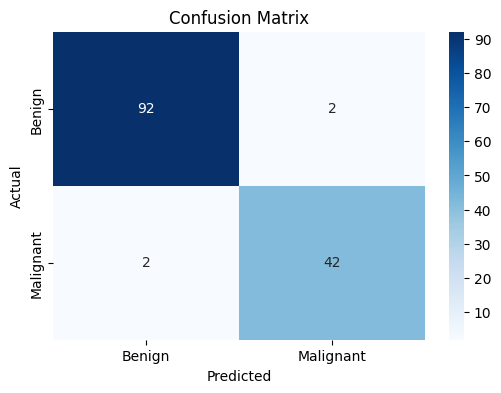

In [ ]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

we have four errors 2 paitents was predicted to have a malignant tumor but they were benign which is bad but fortunatly they won't die on the other hand we have 2 patients that are predridected to have a benign but they have a malignant tumor meaning there life is at risk but they thionk they're okay

In [ ]:
import numpy as np

# Calculate class distribution
classes, counts = np.unique(y_test, return_counts=True)
imbalance_ratio = max(counts) / min(counts)

print(f"Benign cases in test set: {counts[0]}")
print(f"Malignant cases in test set: {counts[1]}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f}x")

Benign cases in test set: 94
Malignant cases in test set: 44
Imbalance Ratio: 2.14x


we notice that the data has some bias since benign cases are and malignant cases are less

### Task 8: Bias and Ethics Report

Evaluating this breast cancer diagnosis model reveals critical ethical considerations regarding misclassification errors and dataset bias. A technical bias check indicates a disparity in class distributions; if the model trains on skewed historical data, it risk-optimizes for the majority class, leading to severe clinical consequences.

Not all diagnostic errors are equal. A False Positive error—predicting a tumor is malignant when it is benign—is bad, causing extreme patient anxiety and unnecessary invasive procedures. However, a False Negative error—misclassifying a malignant tumor as benign—is the worst possible outcome. It grants a false sense of security while a life-threatening disease goes untreated, potentially causing irreversible harm or death.

Therefore, deploying AI in healthcare requires rigorous human oversight. The model must strictly serve as a decision-support tool rather than an independent diagnostic authority, ensuring medical professionals continuously audit predictions to safeguard patient welfare.